In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_variants_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")

In [4]:
#Keep only EG samples
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] == 'EG'].copy()

In [5]:
annotated_variants_df.columns.to_list()

['Guide',
 'Editor',
 'Gene',
 'Cell_Line',
 'Drug',
 'zscore',
 'Hit_class',
 'Source',
 'Target Transcript ID',
 'uniprot_accession',
 'RefSeq match transcript (MANE Select)',
 'Amino Acid Edits',
 'aa_change',
 'Mutation_Category_enc',
 'IMPACT_enc',
 'TSL',
 'SIFT_pathogenicity',
 'PolyPhen_pathogenicity',
 'REVEL',
 'ClinPred',
 'EVE_SCORE',
 'AlphaMissense_score',
 'BayesDel_noAF_score',
 'DANN_score',
 'DEOGEN2_score',
 'ESM1b_score',
 'Eigen-PC-phred_coding',
 'Eigen-PC-raw_coding',
 'GERP++_NR',
 'GERP++_RS',
 'LIST-S2_score',
 'MPC_rankscore',
 'MPC_score',
 'MVP_score',
 'MetaRNN_score',
 'MetaSVM_score',
 'MutFormer_score',
 'MutationAssessor_score',
 'PROVEAN_score',
 'PrimateAI_pred_enc',
 'VARITY_R_LOO_score',
 'bStatistic',
 'fathmm-XF_coding_score',
 'gMVP_score',
 'phastCons100way_vertebrate',
 'phyloP100way_vertebrate',
 'CADD_PHRED',
 'MaxEntScan_alt',
 'MaxEntScan_diff',
 'MaxEntScan_ref',
 'SpliceAI_pred_DP_AG',
 'SpliceAI_pred_DP_AL',
 'SpliceAI_pred_DP_DG',
 'Sp

# Z-scores variances analysis

In [8]:
var_df = (
    annotated_variants_df
    .groupby(["Gene", "Cell_Line"])["zscore"]
    .var()
    .reset_index()
)

In [12]:
var_pivot = var_df.pivot(index="Gene", columns="Cell_Line", values="zscore")

In [13]:
var_df.head()

,Gene,Cell_Line,zscore
0,AKT1,A375,0.324782
1,AKT1,HT29,0.262784
2,BRAF,A375,0.375133
3,BRAF,HT29,0.263586
4,EGFR,A375,0.298124


In [14]:
var_pivot.head()

Cell_Line,A375,HT29
Gene,,
AKT1,0.324782,0.262784
BRAF,0.375133,0.263586
EGFR,0.298124,0.353894
ERBB2,0.327370,0.259945
ERBB3,0.305454,0.187297


In [15]:
from scipy.stats import spearmanr

rho, p = spearmanr(var_pivot["A375"], var_pivot["HT29"])
print(f"Spearman rho = {rho:.3f}, p = {p:.3e}")

Spearman rho = 0.406, p = 2.600e-02


In [60]:
var_per_condition = (
    annotated_variants_df.groupby(["Cell_Line", "Drug", "Gene"])["zscore"]
      .var()
      .reset_index()
)

In [64]:
pivot_PIC = var_per_condition[var_per_condition["Drug"] == 'PIC'].pivot(index="Gene", columns="Cell_Line", values="zscore")
pivot_SCH = var_per_condition[var_per_condition["Drug"] == 'SCH'].pivot(index="Gene", columns="Cell_Line", values="zscore")
pivot_LIN = var_per_condition[var_per_condition["Drug"] == 'LIN'].pivot(index="Gene", columns="Cell_Line", values="zscore")

In [65]:
var_per_condition.head()

,Cell_Line,Drug,Gene,zscore
0,A375,LIN,AKT1,0.321334
1,A375,LIN,BRAF,0.349828
2,A375,LIN,EGFR,0.317273
3,A375,LIN,ERBB2,0.338044
4,A375,LIN,ERBB3,0.319626


In [70]:
pivot_LIN.head()

Cell_Line,A375,HT29
Gene,,
AKT1,0.321334,0.293059
BRAF,0.349828,0.086168
EGFR,0.317273,0.172031
ERBB2,0.338044,0.090415
ERBB3,0.319626,0.107469


In [71]:
rho_pic, p_pic = spearmanr(pivot_PIC["A375"], pivot_PIC["HT29"])
rho_sch, p_sch = spearmanr(pivot_SCH["A375"], pivot_SCH["HT29"])
rho_lin, p_lin = spearmanr(pivot_LIN["A375"], pivot_LIN["HT29"])
print(f"Spearman rho PIC = {rho_pic:.3f}, p = {p_pic:.3e}")
print(f"Spearman rho SCH = {rho_sch:.3f}, p = {p_sch:.3e}")
print(f"Spearman rho LIN = {rho_lin:.3f}, p = {p_lin:.3e}")

Spearman rho PIC = 0.454, p = 1.172e-02
Spearman rho SCH = 0.050, p = 7.928e-01
Spearman rho LIN = 0.359, p = 5.149e-02


In [177]:
lim_min = 0.02
lim_max =1.45

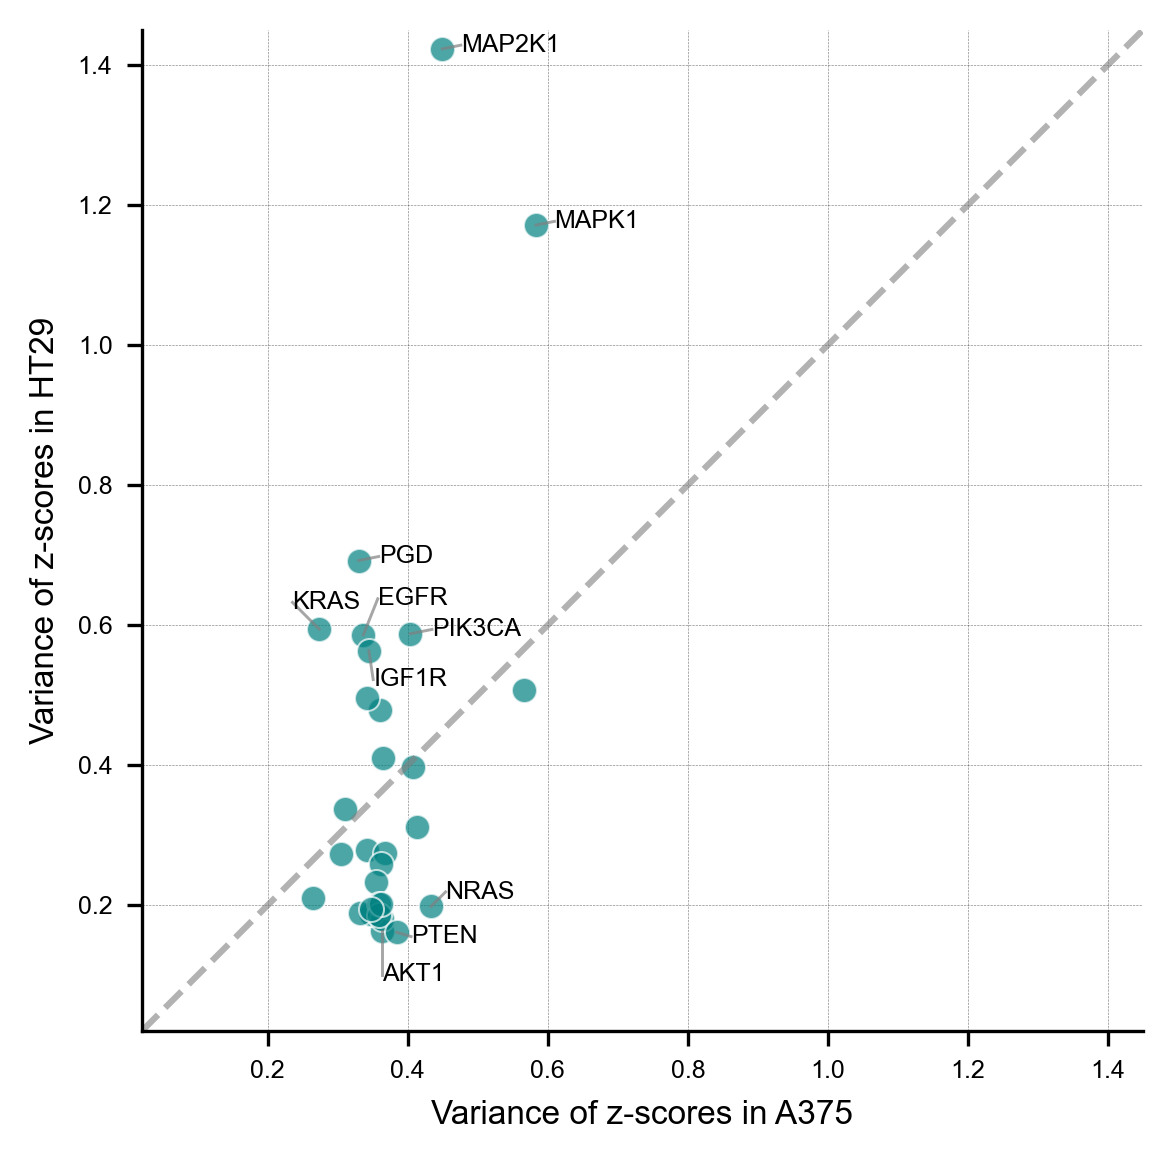

In [189]:
from matplotlib.ticker import MultipleLocator
plt.figure(figsize=(4,4))
sns.scatterplot(
    data=pivot_SCH,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)

# Select top genes by difference
pivot_SCH["diff"] = abs(pivot_SCH["A375"] - pivot_SCH["HT29"])
top_genes = pivot_SCH.sort_values("diff", ascending=False).head(10)

offsets = {
    "PIK3CA": (15, 3),
    "MAPK1": (15,3),
    "MAP2K1": (15, 3),
    "MAP2K2": (4,3),
    "IGF1R": (3, -20),
    "PKM": (4, 3),
    "PGD": (15, 3),
    "MAP2K2": (3, -8),
    "RICTOR": (4, 0),
    "ITGA3": (3, -8),
    "PTEN": (10, -3),
    "MTOR": (-5, 5),
    "KRAS": (-20,20),
    "NRAS": (10,10),
    "EGFR": (10, 25),
    "AKT1": (0,-30)
}

for gene, row in top_genes.iterrows():
    dx, dy = offsets.get(gene, (5, 5))

    # Convert offset from "points" to data coordinates (important!)
    # This keeps behavior consistent with your previous plot
    x = row["A375"]
    y = row["HT29"]

    # Scale offsets (tweak if needed depending on axis range)
    scale = (plt.xlim()[1] - plt.xlim()[0]) * 0.005
    dx_data = dx * scale
    dy_data = dy * scale

    # Text
    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    # Connector line
    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )
    
plt.xlabel("Variance of z-scores in A375", fontsize=8)
plt.ylabel("Variance of z-scores in HT29", fontsize=8)
min_val = min(pivot_SCH["A375"].min(), pivot_SCH["HT29"].min())
max_val = max(pivot_SCH["A375"].max(), pivot_SCH["HT29"].max())
plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))


#plt.title(f"Gene-level variance correlation (rho={rho:.2f})")
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', alpha=0.6)
plt.tight_layout()
plt.show()

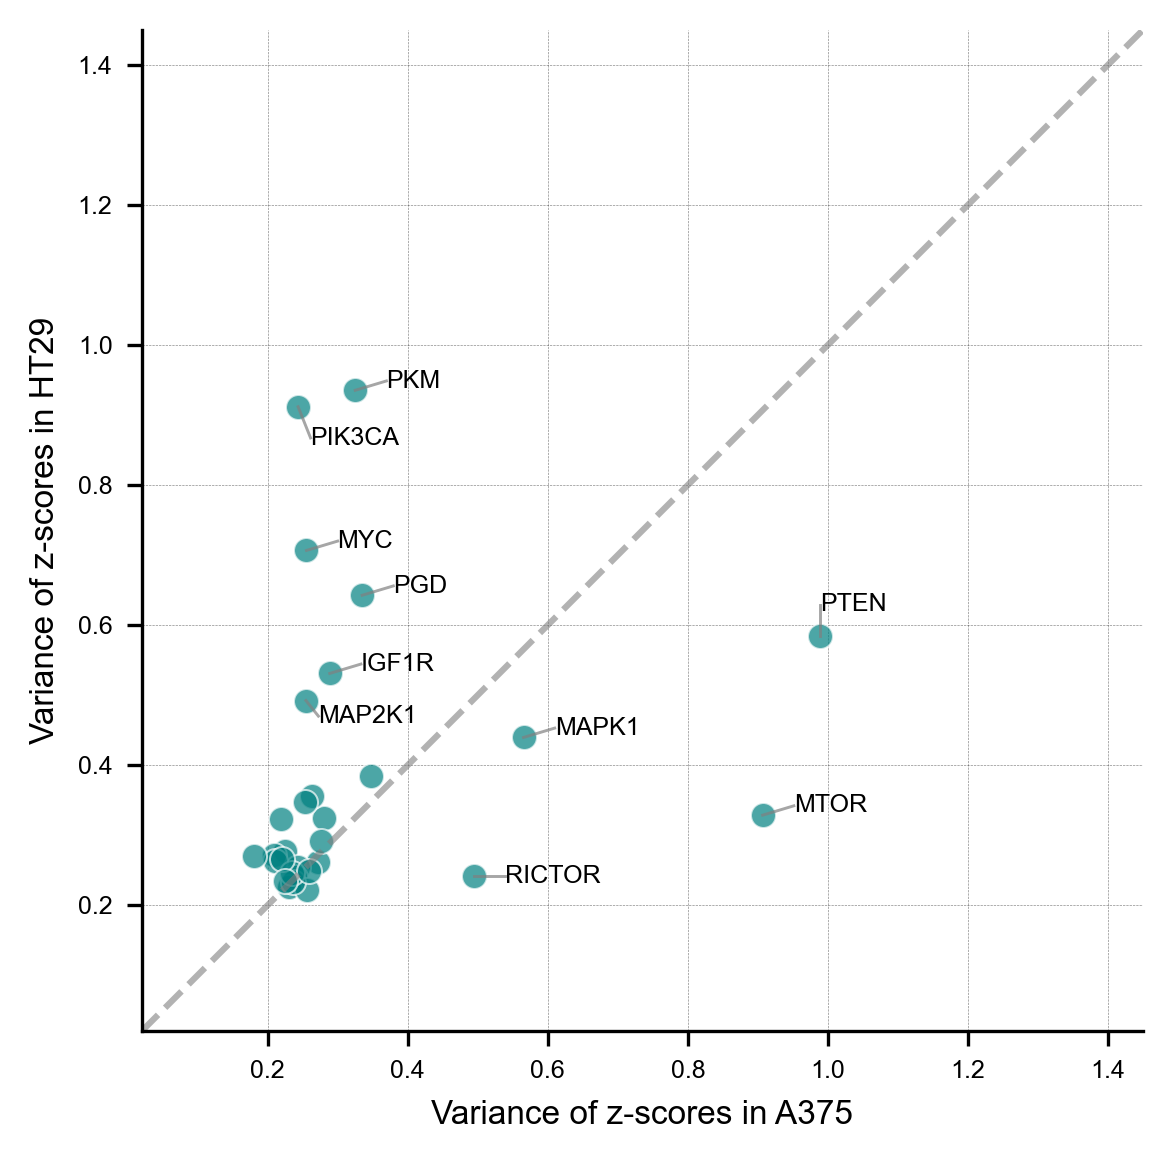

In [188]:
plt.figure(figsize=(4,4))
sns.scatterplot(
    data=pivot_PIC,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)

# Select top genes by difference
pivot_PIC["diff"] = abs(pivot_PIC["A375"] - pivot_PIC["HT29"])
top_genes = pivot_PIC.sort_values("diff", ascending=False).head(10)

offsets = {
    "PIK3CA": (4, -10),
    "MAPK1": (10,3),
    "MAP2K1": (4, -5),
    "MAP2K2": (10,3),
    "IGF1R": (10, 3),
    "PKM": (10, 3),
    "PGD": (10, 3),
    "MAP2K2": (3, -8),
    "RICTOR": (10, 0),
    "ITGA3": (3, -8),
    "PTEN": (0, 10),
    "MTOR": (10, 3),
    "KRAS": (-20,15),
    "NRAS": (10,10),
    "EGFR": (10, 25),
    "AKT1": (-50,-2),
    "MYC": (10,3) 
}

for gene, row in top_genes.iterrows():
    dx, dy = offsets.get(gene, (5, 5))

    # Convert offset from "points" to data coordinates (important!)
    # This keeps behavior consistent with your previous plot
    x = row["A375"]
    y = row["HT29"]

    # Scale offsets (tweak if needed depending on axis range)
    scale = (plt.xlim()[1] - plt.xlim()[0]) * 0.005
    dx_data = dx * scale
    dy_data = dy * scale

    # Text
    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    # Connector line
    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )
    
plt.xlabel("Variance of z-scores in A375", fontsize=8)
plt.ylabel("Variance of z-scores in HT29", fontsize=8)

plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

#plt.title(f"Gene-level variance correlation (rho={rho:.2f})")
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', alpha=0.6)
plt.tight_layout()
plt.show()

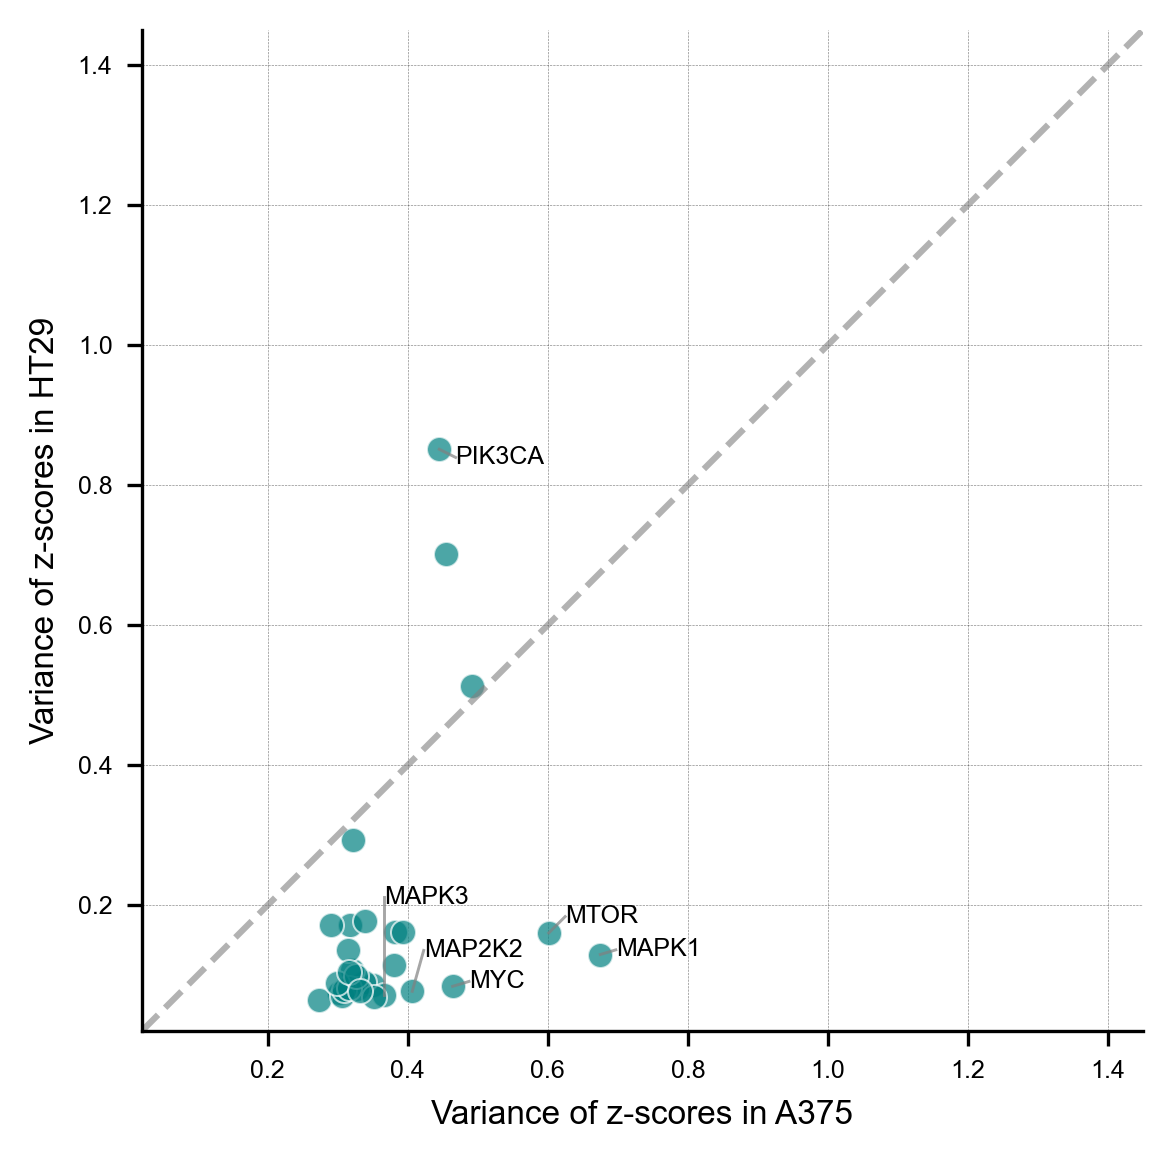

In [187]:
plt.figure(figsize=(4,4))
sns.scatterplot(
    data=pivot_LIN,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)

# Select top genes by difference
pivot_LIN["diff"] = abs(pivot_LIN["A375"] - pivot_LIN["HT29"])
top_genes = pivot_LIN.sort_values("diff", ascending=False).head(6)

offsets = {
    "PIK3CA": (10, -5),
    "MAPK1": (10,3),
    "MAP2K1": (4, -5),
    "IGF1R": (4, 3),
    "PKM": (4, 3),
    "PGD": (4, 3),
    "MAP2K2": (7, 25),
    "RICTOR": (4, 0),
    "ITGA3": (3, -8),
    "PTEN": (-5, 5),
    "MTOR": (10, 10),
    "KRAS": (-20,15),
    "NRAS": (10,10),
    "EGFR": (10, 25),
    "AKT1": (-50,-2),
    "MYC": (10,3),
    "MAPK3": (-0, 60) 
}

for gene, row in top_genes.iterrows():
    dx, dy = offsets.get(gene, (5, 5))

    # Convert offset from "points" to data coordinates (important!)
    # This keeps behavior consistent with your previous plot
    x = row["A375"]
    y = row["HT29"]

    # Scale offsets (tweak if needed depending on axis range)
    scale = (plt.xlim()[1] - plt.xlim()[0]) * 0.005
    dx_data = dx * scale
    dy_data = dy * scale

    # Text
    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    # Connector line
    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )
    
plt.xlabel("Variance of z-scores in A375", fontsize=8)
plt.ylabel("Variance of z-scores in HT29", fontsize=8)


plt.xlim(lim_min, lim_max)
plt.ylim(lim_min, lim_max)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))

#plt.title(f"Gene-level variance correlation (rho={rho:.2f})")
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', alpha=0.6)
plt.tight_layout()
plt.show()

In [172]:
min_val

np.float64(0.06451841722814963)

In [170]:
top_genes

Cell_Line,A375,HT29,diff
Gene,,,
MAP2K1,0.449364,1.422893,0.973530
MAPK1,0.583135,1.171252,0.588116
PGD,0.329871,0.692160,0.362289
KRAS,0.273333,0.594335,0.321001
EGFR,0.336532,0.586038,0.249506
NRAS,0.433423,0.198314,0.235109
PTEN,0.384113,0.161277,0.222835
IGF1R,0.344418,0.563345,0.218927
AKT1,0.362941,0.162374,0.200567


In [81]:
pivot_SCH

Cell_Line,A375,HT29,diff
Gene,,,
AKT1,0.362941,0.162374,0.200567
BRAF,0.413540,0.311484,0.102055
EGFR,0.336532,0.586038,0.249506
ERBB2,0.365140,0.410695,0.045555
ERBB3,0.347802,0.186851,0.160951
FGFR2,0.332357,0.188278,0.144079
GAB1,0.341331,0.278327,0.063005
GRB2,0.367877,0.273899,0.093978
HRAS,0.263939,0.209832,0.054106


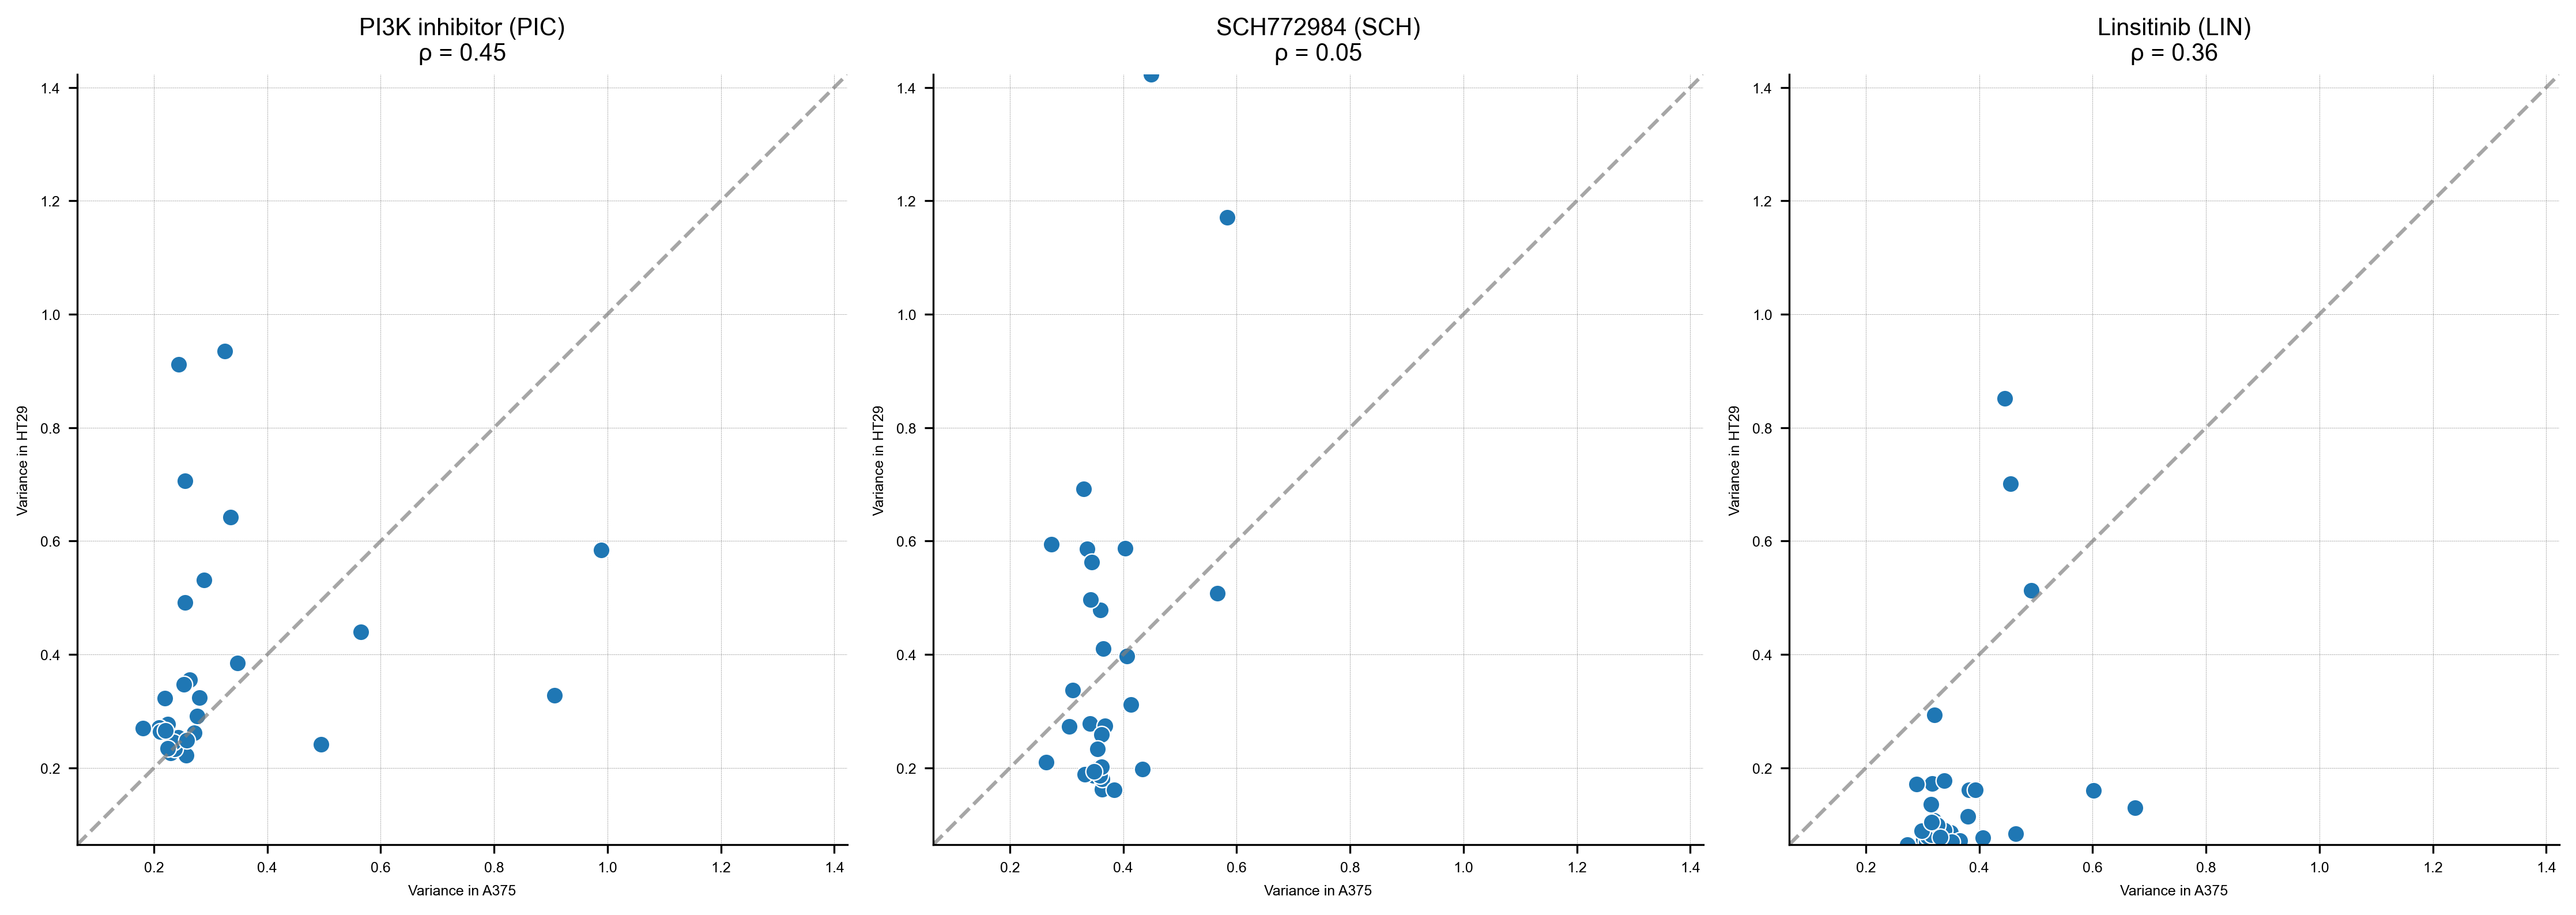

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

pivots = {
    "PI3K inhibitor (PIC)": pivot_PIC,
    "SCH772984 (SCH)": pivot_SCH,
    "Linsitinib (LIN)": pivot_LIN
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Get global limits (important for comparability)
all_vals = []
for pivot in pivots.values():
    all_vals.append(pivot.values.flatten())

import numpy as np
all_vals = np.concatenate(all_vals)
min_val = np.nanmin(all_vals)
max_val = np.nanmax(all_vals)

for ax, (drug_name, pivot) in zip(axes, pivots.items()):

    pivot = pivot.dropna()

    # correlation
    rho, _ = spearmanr(pivot["A375"], pivot["HT29"])

    sns.scatterplot(
        data=pivot,
        x="A375",
        y="HT29",
        ax=ax,
        s=50
    )

    # equal scale
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal')

    # diagonal
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="gray",
        alpha=0.7
    )

    ax.set_title(f"{drug_name}\nρ = {rho:.2f}", fontsize=10)

    ax.set_xlabel("Variance in A375")
    ax.set_ylabel("Variance in HT29")

plt.tight_layout()
plt.show()

## Mean 

In [6]:
from scipy.stats import spearmanr
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# Compute mean z-scores per gene / cell line / drug
# =========================================================

mean_per_condition = (
    annotated_variants_df
    .groupby(["Cell_Line", "Drug", "Gene"])["zscore"]
    .mean()
    .reset_index()
)

# =========================================================
# Pivot tables
# =========================================================

pivot_SCH_mean = mean_per_condition[
    mean_per_condition["Drug"] == "SCH"
].pivot(index="Gene", columns="Cell_Line", values="zscore")

pivot_PIC_mean = mean_per_condition[
    mean_per_condition["Drug"] == "PIC"
].pivot(index="Gene", columns="Cell_Line", values="zscore")

pivot_LIN_mean = mean_per_condition[
    mean_per_condition["Drug"] == "LIN"
].pivot(index="Gene", columns="Cell_Line", values="zscore")

# =========================================================
# Spearman correlations
# =========================================================

rho_sch, p_sch = spearmanr(
    pivot_SCH_mean["A375"],
    pivot_SCH_mean["HT29"]
)

rho_pic, p_pic = spearmanr(
    pivot_PIC_mean["A375"],
    pivot_PIC_mean["HT29"]
)

rho_lin, p_lin = spearmanr(
    pivot_LIN_mean["A375"],
    pivot_LIN_mean["HT29"]
)

print(f"SCH mean rho = {rho_sch:.3f}, p = {p_sch:.3e}")
print(f"PIC mean rho = {rho_pic:.3f}, p = {p_pic:.3e}")
print(f"LIN mean rho = {rho_lin:.3f}, p = {p_lin:.3e}")

# =========================================================
# Shared limits
# =========================================================

all_values = np.concatenate([
    pivot_SCH_mean[["A375", "HT29"]].values.flatten(),
    pivot_PIC_mean[["A375", "HT29"]].values.flatten(),
    pivot_LIN_mean[["A375", "HT29"]].values.flatten()
])

lim_min = np.nanmin(all_values)
lim_max = np.nanmax(all_values)

padding = 0.2

lim_min -= padding
lim_max += padding


SCH mean rho = 0.211, p = 2.638e-01
PIC mean rho = 0.103, p = 5.864e-01
LIN mean rho = 0.322, p = 8.233e-02


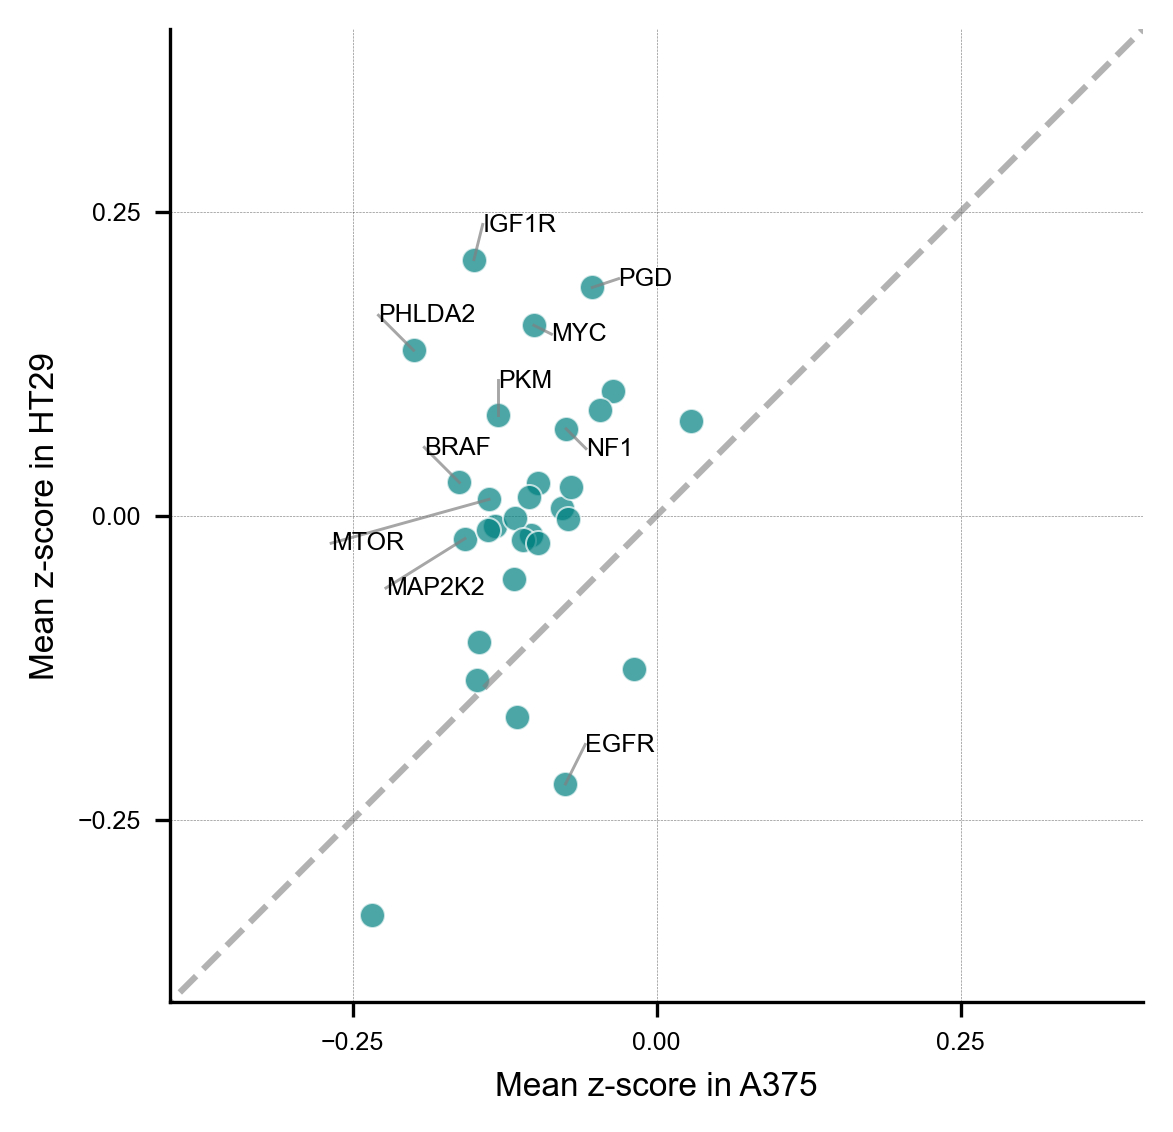

In [103]:
# SCH


plt.figure(figsize=(4,4))

sns.scatterplot(
    data=pivot_SCH_mean,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)

pivot_SCH_mean = pivot_SCH_mean.copy()
pivot_SCH_mean["diff"] = abs(
    pivot_SCH_mean["A375"] - pivot_SCH_mean["HT29"]
)

top_genes = (
    pivot_SCH_mean
    .sort_values("diff", ascending=False)
    .head(10)
)

offsets_sch = {

    "PIK3CA": (15, 5),
    "MAPK1": (15, 5),
    "MAP2K2": (-40, -25),
    "IGF1R": (5, 20),
    "PGD": (15, 5),
    "KRAS": (-20, 15),
    "NRAS": (10, 10),
    "EGFR": (10, 20),
    "PTEN": (10, -10),
    "AKT1": (0, -20),
    "PHLDA2": (-20, 20),
    "MYC": (10, -5),
    'PKM': (0, 20),
    'NF1': (10, -10),
    'BRAF': (-20, 20),
    'MTOR': (-90, -25)

}

for gene, row in top_genes.iterrows():

    x = row["A375"]
    y = row["HT29"]

    dx, dy = offsets_sch.get(gene, (5, 5))

    scale = (plt.xlim()[1] - plt.xlim()[0]) * 0.005

    dx_data = dx * scale
    dy_data = dy * scale

    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    color="gray",
    alpha=0.6
)

plt.xlabel("Mean z-score in A375", fontsize=8)
plt.ylabel("Mean z-score in HT29", fontsize=8)

plt.xlim(-0.4, 0.4)
plt.ylim(-0.4, 0.4)

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')

ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.yaxis.set_major_locator(MultipleLocator(0.25))

plt.tight_layout()
plt.show()

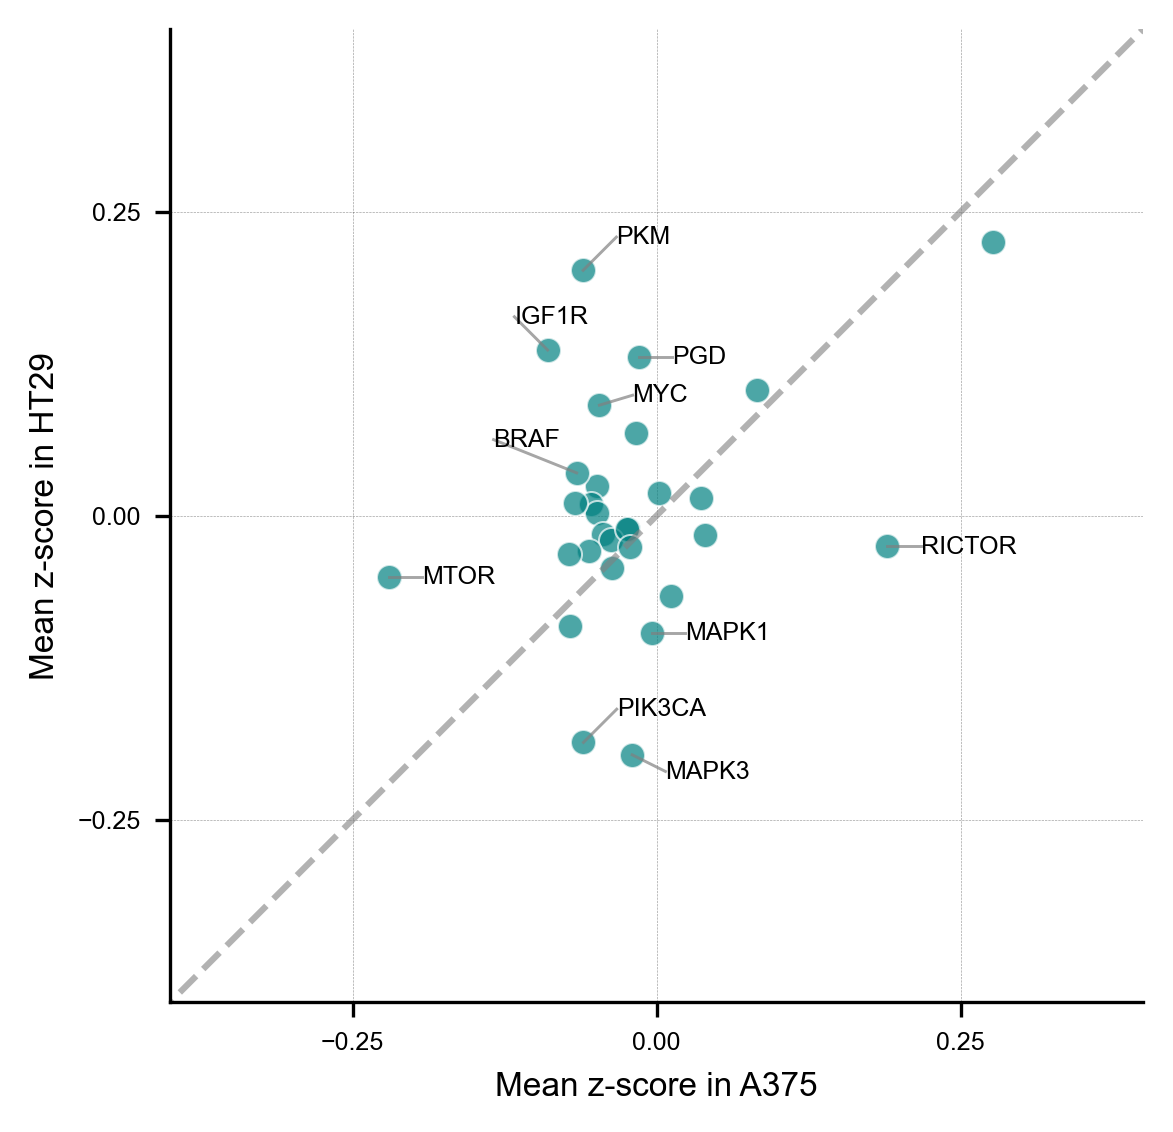

In [96]:
# PIC 


plt.figure(figsize=(4,4))

sns.scatterplot(
    data=pivot_PIC_mean,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)


# Difference between cell lines
pivot_PIC_mean = pivot_PIC_mean.copy()

pivot_PIC_mean["diff"] = abs(
    pivot_PIC_mean["A375"] - pivot_PIC_mean["HT29"]
)

top_genes = (
    pivot_PIC_mean
    .sort_values("diff", ascending=False)
    .head(10)
)


# Manual label offsets
offsets_pic = {

    "PIK3CA": (10, 10),
    "PKM": (10, 10),
    "MYC": (10, 3),
    "PGD": (10, 0),
    "IGF1R": (-10, 10),
    "MAPK3": (10, -5),
    "MAPK1": (10, 0),
    "RICTOR": (10, 0),
    "PTEN": (10, 10),
    "MTOR": (10, 0),
    'BRAF': (-25, 10),

}

# Annotate genes
for gene, row in top_genes.iterrows():

    x = row["A375"]
    y = row["HT29"]

    dx, dy = offsets_pic.get(gene, (5, 5))

    # Convert point offsets to data coordinates
    scale = (plt.xlim()[1] - plt.xlim()[0]) * 0.005

    dx_data = dx * scale
    dy_data = dy * scale

    # Text
    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    # Connector line
    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )

# Diagonal

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    color="gray",
    alpha=0.6
)


# Axes

plt.xlabel("Mean z-score in A375", fontsize=8)
plt.ylabel("Mean z-score in HT29", fontsize=8)

plt.xlim(-0.4, 0.4)
plt.ylim(-0.4, 0.4)

ax = plt.gca()

ax.set_aspect('equal', adjustable='box')

ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.yaxis.set_major_locator(MultipleLocator(0.25))

plt.grid(alpha=0.4)

# Optional title
# plt.title(f"PIC (rho = {rho_pic:.2f})", fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
annotated_variants_df['Gene'].value_counts()

Gene
MTOR      9198
NF1       8010
ERBB3     5340
ERBB2     5088
RICTOR    4638
IGF1R     4608
PIK3CD    4404
ITGA3     4272
EGFR      4194
PIK3CB    2754
PIK3CA    2724
FGFR2     2688
SHC1      2490
RAF1      2202
BRAF      2124
GAB1      2052
PKM       1956
AKT1      1860
PGD       1752
MAP2K2    1590
MAPK3     1506
MYC       1506
MAP2K1    1458
MAPK1     1188
PTEN      1086
GRB2       858
HRAS       708
PHLDA2     660
NRAS       588
KRAS       522
Name: count, dtype: int64

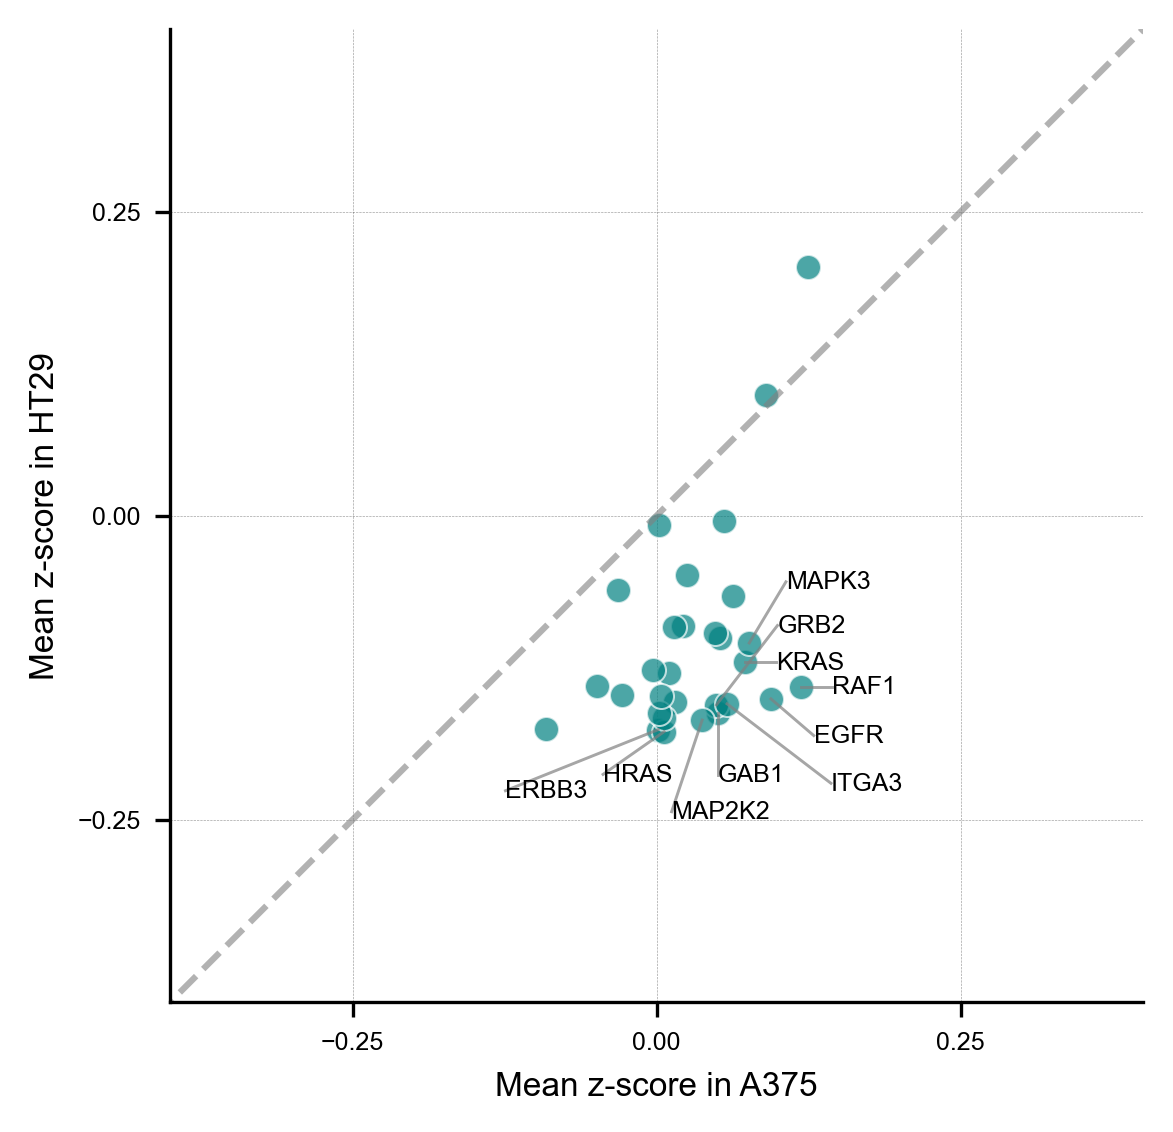

In [121]:
# LIN 


plt.figure(figsize=(4,4))

sns.scatterplot(
    data=pivot_LIN_mean,
    x="A375",
    y="HT29",
    color="teal",
    alpha=0.7
)


# Set limits BEFORE annotations
plt.xlim(-0.4, 0.4)
plt.ylim(-0.4, 0.4)

# Fixed scaling factor for offsets
scale = (lim_max - lim_min) * 0.005


# Difference between cell lines
pivot_LIN_mean = pivot_LIN_mean.copy()

pivot_LIN_mean["diff"] = abs(
    pivot_LIN_mean["A375"] - pivot_LIN_mean["HT29"]
)

top_genes = (
    pivot_LIN_mean
    .sort_values("diff", ascending=False)
    .head(10)
)

# Manual label offsets

offsets_lin = {

    "PIK3CA": (10, 10),
    "MAPK3": (6, 10),
    "MAP2K2": (-5, -15),
    "MYC": (10, -5),
    "MTOR": (10, 5),
    "MAPK1": (10, -5),
    "KRAS": (5, 0),
    "RAF1": (5, 0),
    "ERBB3": (-25, -10),
    'EGFR': (7, -6),
    'HRAS': (-10, -7),
    'GAB1': (0, -10),
    'ITGA3': (17, -13),
    'GRB2': (10, 13)


}

# Annotate genes

for gene, row in top_genes.iterrows():

    x = row["A375"]
    y = row["HT29"]

    dx, dy = offsets_lin.get(gene, (5, 5))

    # Convert point offsets → data coordinates
    dx_data = dx * scale
    dy_data = dy * scale

    # Text
    plt.text(
        x + dx_data,
        y + dy_data,
        gene,
        fontsize=6,
        ha="left",
        va="center"
    )

    # Connector line
    plt.plot(
        [x, x + dx_data],
        [y, y + dy_data],
        color="gray",
        lw=0.7,
        alpha=0.7
    )

# Diagonal

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    color="gray",
    alpha=0.6
)

# Axes

plt.xlabel("Mean z-score in A375", fontsize=8)
plt.ylabel("Mean z-score in HT29", fontsize=8)

ax = plt.gca()

ax.set_aspect('equal', adjustable='box')

ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.yaxis.set_major_locator(MultipleLocator(0.25))

plt.grid(alpha=0.4)

# Optional title
# plt.title(f"LIN (rho = {rho_lin:.2f})", fontsize=9)

plt.tight_layout()
plt.show()